In [1]:
import pandas as pd
from pandas import DataFrame
from pathlib import Path
import datetime
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, accuracy_score, confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import pyplot
 

#import file
train = pd.read_csv('/Users/ericmerdian/Desktop/Desktop/A_Summer_Research/AllTeams/training.csv')
test = pd.read_csv('/Users/ericmerdian/Desktop/Desktop/A_Summer_Research/AllTeams/testing.csv')

# #time column is not needed
# df = df.drop('Time',1)

# print(df['Possession'].isna().sum())
# #there are 1075 null values for possession

# #drop rows where possession is null
# df = df[df['Possession'].notna()]


# df['GameDatetime'] = pd.to_datetime(df['GameDate'])
# df = df.drop('GameDate',1)

#home team score and point differential
                        
train.head()

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,NaN,NaN,1.0,NaN,2386
1,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,NaN,NaN,1.0,NaN,2386
2,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,0.0,0.0,1.0,NaN,2354
3,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,2,2,1,0.0,0.0,1.0,NaN,2354
4,18_11_10_4_01,Hendrix,Texas-Dallas,0.5,0.5,Win,0,4,4,1,0.0,0.0,1.0,NaN,2344


In [2]:
test

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
0,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,1.000,NaN,NaN,NaN,2376
1,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2344
2,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2344
3,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2334
4,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0,2,2.0,1,0.500,0.000,NaN,NaN,2334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42222,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,79,15.0,2,0.458,0.375,0.574,0.522,51
42223,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,79,15.0,2,0.458,0.375,0.574,0.522,51
42224,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,82,18.0,2,0.458,0.375,0.580,0.542,22
42225,19_02_22_4_27,Hendrix,Sewanee,0.4,0.760,Win,64,82,18.0,2,0.452,0.364,0.580,0.542,16


In [3]:
test[test['GameID'] ==  '19_01_27_2_20']

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
2427,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,NaN,NaN,2382
2428,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,NaN,NaN,2382
2429,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.000,NaN,2350
2430,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.000,NaN,2350
2431,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.000,NaN,2340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2900,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,71,17.0,2,0.467,0.269,0.493,0.333,36
2901,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,71,17.0,2,0.467,0.269,0.493,0.333,36
2902,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,73,19.0,2,0.467,0.269,0.500,0.333,30
2903,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,73,19.0,2,0.459,0.259,0.500,0.333,20


In [4]:

## one-hot encode

#add win and loss column
df_add1 = pd.get_dummies(train.Outcome, prefix = 'Outcome',drop_first = True)

train = pd.concat([train,df_add1], axis=1)
test = pd.concat([test,df_add1], axis=1)




In [5]:
train.groupby(['GameID', 'Outcome_Win']).ngroups

85

In [6]:
game_outcome = train.groupby(["GameID", "Outcome_Win"]).size().reset_index()

In [7]:
game_outcome

,GameID,Outcome_Win,0
0,18_11_06_7_01,1,571
1,18_11_09_6_01,1,651
2,18_11_09_7_02,1,536
3,18_11_10_2_01,1,621
4,18_11_10_4_01,1,502
...,...,...,...
80,19_01_01_2_12,1,570
81,19_01_01_5_12,1,570
82,19_01_02_4_13,0,537
83,19_01_04_1_12,0,598


In [8]:
game_outcome = pd.DataFrame(game_outcome)

In [9]:
game_outcome

,GameID,Outcome_Win,0
0,18_11_06_7_01,1,571
1,18_11_09_6_01,1,651
2,18_11_09_7_02,1,536
3,18_11_10_2_01,1,621
4,18_11_10_4_01,1,502
...,...,...,...
80,19_01_01_2_12,1,570
81,19_01_01_5_12,1,570
82,19_01_02_4_13,0,537
83,19_01_04_1_12,0,598


Based on the cell below, we can see that there are 24 more home games won than lost in this dataset.

In [10]:
game_outcome.groupby(['Outcome_Win']).size()

Outcome_Win
0    31
1    54
dtype: int64

In [11]:
game_outcome

,GameID,Outcome_Win,0
0,18_11_06_7_01,1,571
1,18_11_09_6_01,1,651
2,18_11_09_7_02,1,536
3,18_11_10_2_01,1,621
4,18_11_10_4_01,1,502
...,...,...,...
80,19_01_01_2_12,1,570
81,19_01_01_5_12,1,570
82,19_01_02_4_13,0,537
83,19_01_04_1_12,0,598


In [12]:
game_wins = game_outcome[game_outcome['Outcome_Win'] ==  1]
game_wins

,GameID,Outcome_Win,0
0,18_11_06_7_01,1,571
1,18_11_09_6_01,1,651
2,18_11_09_7_02,1,536
3,18_11_10_2_01,1,621
4,18_11_10_4_01,1,502
5,18_11_11_6_02,1,580
6,18_11_12_2_02,1,561
7,18_11_13_1_01,1,580
9,18_11_13_4_02,1,496
10,18_11_13_5_01,1,638


In [13]:
game_losses = game_outcome[game_outcome['Outcome_Win'] ==  0]
game_losses

,GameID,Outcome_Win,0
8,18_11_13_3_01,0,472
11,18_11_13_7_03,0,487
15,18_11_16_2_04,0,552
17,18_11_17_1_03,0,515
20,18_11_17_6_03,0,33
22,18_11_18_4_05,0,411
24,18_11_18_6_04,0,612
28,18_11_20_4_06,0,481
29,18_11_20_7_06,0,445
35,18_11_24_3_04,0,455


Because we want to have the same amount of wins as losses and there were 31 games lost by the home team in our training data, I then extracted 31 random game id's from the games won by the home team.

In [14]:
remove_n = 31
drop_indices = np.random.choice(game_wins.index, remove_n, replace=False)
df_subset = game_wins.drop(drop_indices)

In [15]:
len(df_subset)

23

In [16]:
remaining_games = df_subset['GameID']
remaining_games = pd.DataFrame(remaining_games)

In [17]:
len(remaining_games)

23

After all was said and done, we were left with 23 games won by the home team to filter out of our training set.

In [18]:
game_ids = remaining_games['GameID'].unique()
game_ids

array(['18_11_10_4_01', '18_11_13_1_01', '18_11_13_5_01', '18_11_14_2_03',
       '18_11_17_4_04', '18_11_17_7_05', '18_11_19_2_05', '18_11_21_6_05',
       '18_11_24_1_05', '18_11_25_2_07', '18_11_27_3_05', '18_11_27_4_07',
       '18_11_28_7_08', '18_11_29_4_08', '18_12_01_7_09', '18_12_11_1_09',
       '18_12_11_7_11', '18_12_12_3_07', '18_12_15_4_10', '18_12_29_4_12',
       '18_12_29_5_11', '18_12_30_6_11', '19_01_01_2_12'], dtype=object)

In [19]:
len(game_ids)

23

In [20]:
b = np.asarray(game_ids)
b

array(['18_11_10_4_01', '18_11_13_1_01', '18_11_13_5_01', '18_11_14_2_03',
       '18_11_17_4_04', '18_11_17_7_05', '18_11_19_2_05', '18_11_21_6_05',
       '18_11_24_1_05', '18_11_25_2_07', '18_11_27_3_05', '18_11_27_4_07',
       '18_11_28_7_08', '18_11_29_4_08', '18_12_01_7_09', '18_12_11_1_09',
       '18_12_11_7_11', '18_12_12_3_07', '18_12_15_4_10', '18_12_29_4_12',
       '18_12_29_5_11', '18_12_30_6_11', '19_01_01_2_12'], dtype=object)

We have now set our training set to contain 31 games won by the home team and 31 games lost by the home team.

In [21]:
train = train.loc[~train['GameID'].isin(b)]
train

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
502,18_11_13_4_02,Hendrix,UAFS,0.5,0.5,Win,0,3,3,1,NaN,NaN,1.000,1.000,2374,1
503,18_11_13_4_02,Hendrix,UAFS,0.5,0.5,Win,0,3,3,1,NaN,NaN,1.000,1.000,2374,1
504,18_11_13_4_02,Hendrix,UAFS,0.5,0.5,Win,0,3,3,1,NaN,NaN,1.000,1.000,2348,1
505,18_11_13_4_02,Hendrix,UAFS,0.5,0.5,Win,0,3,3,1,NaN,NaN,1.000,1.000,2347,1
506,18_11_13_4_02,Hendrix,UAFS,0.5,0.5,Win,0,5,5,1,NaN,NaN,1.000,1.000,2345,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43180,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9,1
43181,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9,1
43182,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9,1
43183,18_12_29_7_12,Bridgewater (Va.),Sewanee,0.5,0.9,Win,76,79,3,2,0.477,0.269,0.511,0.368,9,1


In [22]:
test_copy = test

In [23]:
test_copy

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0.0,2,2.0,1.0,1.0,NaN,NaN,NaN,2376.0,1
1,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0.0,2,2.0,1.0,0.5,0.0,NaN,NaN,2344.0,1
2,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0.0,2,2.0,1.0,0.5,0.0,NaN,NaN,2344.0,1
3,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0.0,2,2.0,1.0,0.5,0.0,NaN,NaN,2334.0,1
4,19_01_04_2_13,Oglethorpe,Birmingham-Southern,0.5,0.545,Lose,0.0,2,2.0,1.0,0.5,0.0,NaN,NaN,2334.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
43181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
43182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
43183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [24]:
#drop columns that are not used
unused_columns = ['GameID','VisitorName','HomeName', 'Outcome', 'Away Team Score']

train = train.drop(unused_columns, axis = 1)
test = test.drop(unused_columns, axis = 1)

train.head()

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
502,0.5,0.5,3,3,1,NaN,NaN,1.0,1.0,2374,1
503,0.5,0.5,3,3,1,NaN,NaN,1.0,1.0,2374,1
504,0.5,0.5,3,3,1,NaN,NaN,1.0,1.0,2348,1
505,0.5,0.5,3,3,1,NaN,NaN,1.0,1.0,2347,1
506,0.5,0.5,5,5,1,NaN,NaN,1.0,1.0,2345,1


In [25]:
train.describe()

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
count,31653.000000,31653.000000,31653.000000,31653.000000,31653.000000,31446.000000,30865.000000,24764.000000,24333.000000,31653.000000,31653.000000
mean,0.555724,0.498907,37.703219,0.164029,1.531830,0.477780,0.343009,0.480087,0.306670,1144.485799,0.514296
std,0.204761,0.194337,23.282373,12.443762,0.527554,0.121448,0.183939,0.118943,0.161249,697.171806,0.499803
min,0.000000,0.000000,0.000000,-50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.500000,18.000000,-7.000000,1.000000,0.412000,0.250000,0.425000,0.222000,532.000000,0.000000
50%,0.500000,0.500000,36.000000,0.000000,2.000000,0.484000,0.333000,0.486000,0.308000,1162.000000,1.000000
75%,0.556000,0.500000,56.000000,6.000000,2.000000,0.550000,0.417000,0.540000,0.393000,1747.000000,1.000000
max,1.000000,1.000000,103.000000,48.000000,4.000000,1.000000,1.000000,1.000000,1.000000,2400.000000,1.000000


Now that the number of games has been balanced out, it was important to check that the number of rows also balanced our (roughly). Here we can see there are about 600 additional rows for the home team won games, but not a huge deal.

In [26]:
train.groupby(['Outcome_Win']).size()

Outcome_Win
0    15374
1    16279
dtype: int64

In [27]:
test.head()

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,0.5,0.545,2,2.0,1.0,1.0,NaN,NaN,NaN,2376.0,1
1,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2344.0,1
2,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2344.0,1
3,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2334.0,1
4,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2334.0,1


In [28]:
test = test[test['Home Team Score'] != '(+5)']

In [29]:
test_copy = test_copy[test_copy['Home Team Score'] != '(+5)']

In [30]:
test_copy = test_copy[test_copy['Home Team Score'] != '(+1)']

In [31]:
test = test[test['Home Team Score'] != '(+1)']

In [32]:
test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Outcome_Win
0,0.5,0.545,2,2.0,1.0,1.0,NaN,NaN,NaN,2376.0,1
1,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2344.0,1
2,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2344.0,1
3,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2334.0,1
4,0.5,0.545,2,2.0,1.0,0.5,0.0,NaN,NaN,2334.0,1
...,...,...,...,...,...,...,...,...,...,...,...
43180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
43181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
43182,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
43183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [33]:
test = test.dropna()

In [34]:
test_copy = test_copy.dropna()

In [35]:
len(test)

30146

In [36]:
len(test_copy)

30146

In [37]:
train = train.fillna(train.mean())

In [38]:
test = test.fillna(train.mean())

In [39]:
y_train = train['Outcome_Win']
y_test = test['Outcome_Win']

In [40]:
X_train = train.drop(['Outcome_Win'], axis = 1)
X_test = test.drop(['Outcome_Win'], axis = 1)

X_train

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
502,0.5,0.5,3,3,1,0.47778,0.343009,1.000,1.000,2374
503,0.5,0.5,3,3,1,0.47778,0.343009,1.000,1.000,2374
504,0.5,0.5,3,3,1,0.47778,0.343009,1.000,1.000,2348
505,0.5,0.5,3,3,1,0.47778,0.343009,1.000,1.000,2347
506,0.5,0.5,5,5,1,0.47778,0.343009,1.000,1.000,2345
...,...,...,...,...,...,...,...,...,...,...
43180,0.5,0.9,79,3,2,0.47700,0.269000,0.511,0.368,9
43181,0.5,0.9,79,3,2,0.47700,0.269000,0.511,0.368,9
43182,0.5,0.9,79,3,2,0.47700,0.269000,0.511,0.368,9
43183,0.5,0.9,79,3,2,0.47700,0.269000,0.511,0.368,9


In [41]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
2435,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0
2436,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0
2437,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0
2438,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0
2439,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2260.0
...,...,...,...,...,...,...,...,...,...,...
42222,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0
42223,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0
42224,0.400,0.760,82,18.0,2.0,0.458,0.375,0.580,0.542,22.0
42225,0.400,0.760,82,18.0,2.0,0.452,0.364,0.580,0.542,16.0


In [42]:
test_game_ids = test_copy['GameID']

train = train.drop('GameID', axis = 1)
test = test.drop('GameID', axis = 1)

In [43]:
std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

X_train_scaled= std_scaler.fit_transform(X_train)
X_test_scaled= std_scaler.transform(X_test)

X_train_scaled

array([[-0.27214792,  0.00562325, -1.49055975, ...,  4.94193163,
         4.90412039,  1.76360205],
       [-0.27214792,  0.00562325, -1.49055975, ...,  4.94193163,
         4.90412039,  1.76360205],
       [-0.27214792,  0.00562325, -1.49055975, ...,  4.94193163,
         4.90412039,  1.72630792],
       ...,
       [-0.27214792,  2.06393706,  1.77376394, ...,  0.29383333,
         0.43380643, -1.62872871],
       [-0.27214792,  2.06393706,  1.77376394, ...,  0.29383333,
         0.43380643, -1.62872871],
       [-0.27214792,  2.06393706,  1.77376394, ...,  0.29383333,
         0.43380643, -1.63733505]])

In [44]:
X_test_scaled

array([[ 1.34589282e-03,  1.76548155e+00, -1.61941463e+00, ...,
        -4.56338186e+00, -2.16916120e+00,  1.66319479e+00],
       [ 1.34589282e-03,  1.76548155e+00, -1.61941463e+00, ...,
        -4.56338186e+00, -2.16916120e+00,  1.66319479e+00],
       [ 1.34589282e-03,  1.76548155e+00, -1.49055975e+00, ...,
        -1.39811247e+00,  1.36747960e+00,  1.62590067e+00],
       ...,
       [-7.60529732e-01,  1.34352722e+00,  1.90261882e+00, ...,
         9.49699960e-01,  1.66455742e+00, -1.61008165e+00],
       [-7.60529732e-01,  1.34352722e+00,  1.90261882e+00, ...,
         9.49699960e-01,  1.66455742e+00, -1.61868798e+00],
       [-7.60529732e-01,  1.34352722e+00,  1.90261882e+00, ...,
         9.49699960e-01,  1.66455742e+00, -1.61868798e+00]])

In [45]:
logreg = LogisticRegression()

# fit the model with data
logreg.fit(X_train,y_train)

try:
    y_pred=logreg.predict(X_test)
except:
    print("error")

/Users/ericmerdian/opt/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [46]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[ 3609,  8150],
       [ 5828, 12559]])

Compared to the previous model that simply spit out that the home team always won, this is a significant improvement, albeit one that still needs work.

Accuracy: 0.5363232269621176
Precision: 0.6064513013665556
Recall: 0.6830369282645348
F1 Score: 0.6424698178841824
AUC Score: 0.49497539074167296


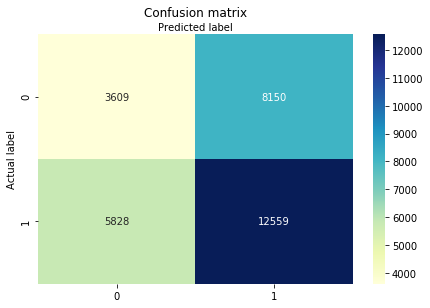

In [47]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("F1 Score:",metrics.f1_score(y_test, y_pred))
print("AUC Score:",metrics.roc_auc_score(y_test, y_pred))
# print("R^2 value: ", logreg.score(X_test.values.reshape(-1, 1), y_test))

In [85]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,WinProb,GameID
2435,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0,0.906766,19_01_27_2_20
2436,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0,0.906766,19_01_27_2_20
2437,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0,0.799257,19_01_27_2_20
2438,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0,0.799257,19_01_27_2_20
2439,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2260.0,0.800062,19_01_27_2_20
...,...,...,...,...,...,...,...,...,...,...,...,...
42222,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42223,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42224,0.400,0.760,82,18.0,2.0,0.458,0.375,0.580,0.542,22.0,0.988547,19_02_22_4_27
42225,0.400,0.760,82,18.0,2.0,0.452,0.364,0.580,0.542,16.0,0.988447,19_02_22_4_27


In [86]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], dtype=uint8)

In [87]:
y_test

2435     0
2436     0
2437     0
2438     0
2439     0
        ..
42222    1
42223    1
42224    1
42225    1
42226    1
Name: Outcome_Win, Length: 30146, dtype: uint8

In [76]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,WinProb,GameID
2435,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0,0.906766,19_01_27_2_20
2436,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0,0.906766,19_01_27_2_20
2437,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0,0.799257,19_01_27_2_20
2438,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0,0.799257,19_01_27_2_20
2439,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2260.0,0.800062,19_01_27_2_20
...,...,...,...,...,...,...,...,...,...,...,...,...
42222,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42223,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42224,0.400,0.760,82,18.0,2.0,0.458,0.375,0.580,0.542,22.0,0.988547,19_02_22_4_27
42225,0.400,0.760,82,18.0,2.0,0.452,0.364,0.580,0.542,16.0,0.988447,19_02_22_4_27


In [78]:
len(y_pred)

30146

In [48]:
data_outcome = pd.DataFrame((y_test == 1) & (y_pred == 0))
data_outcome

,Outcome_Win
2435,False
2436,False
2437,False
2438,False
2439,False
...,...
42222,False
42223,False
42224,False
42225,False


In [49]:
data_outcome.groupby(['Outcome_Win']).size()

Outcome_Win
False    24318
True      5828
dtype: int64

I found the following code online and it has run beofre but doesn't currently for some reason.

In [50]:
clf = LogisticRegression(random_state = 42, max_iter=1000)
clf.fit(X_train,y_train)
classes = logreg.predict(X_test)
probs = logreg.predict_proba(X_test)
print(np.bincount(classes))

[ 9437 20709]


In [89]:
importance = logreg.coef_
print(importance)
# summarize feature importance
# for i,v in enumerate(importance):
# 	print('Feature: %0d, Score: %.5f' % (i,v))

[[-2.62080379e+00  3.66737310e+00 -1.05648991e-02  2.04632436e-01
   2.99705869e-01  4.24738123e-01  2.61223121e-01 -1.01233789e+00
  -1.48980078e+00 -1.67183109e-04]]


Insert a bar chart of these values * 100

In [93]:
cols = []
for i in X_train.columns:
    cols.append(i)

In [94]:
cols

['VisitorWinPercent',
 'HomeWinPercent',
 'Home Team Score',
 'Point Differential',
 'Period',
 'Home Shooting PCT',
 'Home 3PTRs PCT',
 'Away Shooting PCT',
 'Away 3PTRs PCT',
 'Time Remaining Secs']

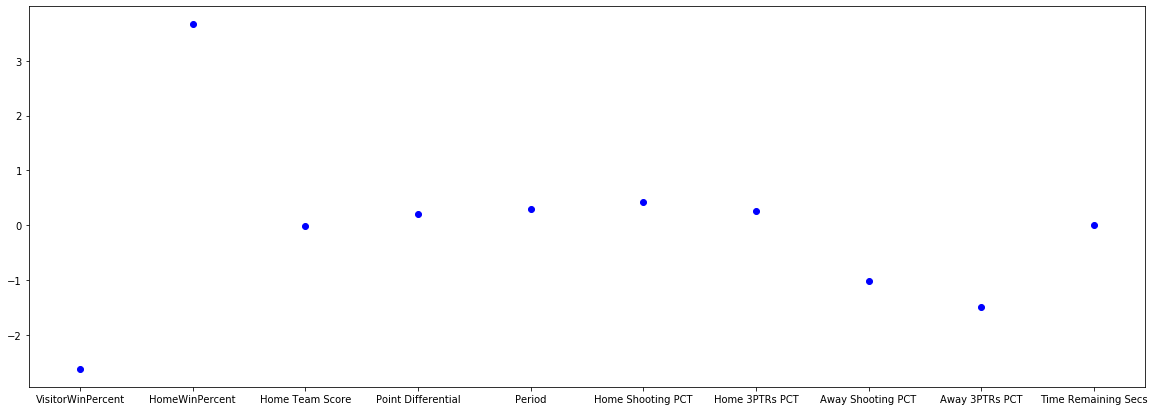

In [96]:
plt.figure(figsize=(20,7))
plt.scatter(cols,importance,c='b')

pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

clf = LogisticRegression(random_state = 42, max_iter=1000)
clf.fit(X_train,y_train)
classes = model.predict(X_test)
probs = model.predict_proba(X_test)
print(np.bincount(classes))

In [52]:
win_prob = clf.predict_proba(X_test)
win_prob

array([[0.09323425, 0.90676575],
       [0.09323425, 0.90676575],
       [0.20074273, 0.79925727],
       ...,
       [0.01145335, 0.98854665],
       [0.01155324, 0.98844676],
       [0.01155324, 0.98844676]])

In [53]:
win_prob = pd.DataFrame(win_prob)

In [54]:
win_prob = win_prob[1]

In [55]:
win_prob

0        0.906766
1        0.906766
2        0.799257
3        0.799257
4        0.800062
           ...   
30141    0.980118
30142    0.980118
30143    0.988547
30144    0.988447
30145    0.988447
Name: 1, Length: 30146, dtype: float64

In [56]:
win_prob = clf.predict_proba(X_test)[:,1]

In [57]:
len(X_test)

30146

In [58]:
sub = X_test

In [59]:
X_test

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
2435,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0
2436,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0
2437,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0
2438,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0
2439,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2260.0
...,...,...,...,...,...,...,...,...,...,...
42222,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0
42223,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0
42224,0.400,0.760,82,18.0,2.0,0.458,0.375,0.580,0.542,22.0
42225,0.400,0.760,82,18.0,2.0,0.452,0.364,0.580,0.542,16.0


In [60]:
X_test.loc[X_test['Period'] == 4]

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs
3412,0.526,0.550,78,0.0,4.0,0.50,0.407,0.500,0.385,300.0
3413,0.526,0.550,78,0.0,4.0,0.50,0.407,0.500,0.385,300.0
3414,0.526,0.550,78,0.0,4.0,0.50,0.407,0.500,0.385,300.0
3415,0.526,0.550,78,0.0,4.0,0.50,0.407,0.500,0.385,300.0
3416,0.526,0.550,80,2.0,4.0,0.50,0.407,0.506,0.385,294.0
...,...,...,...,...,...,...,...,...,...,...
10526,0.476,0.571,72,-5.0,4.0,0.45,0.179,0.475,0.167,2.0
10527,0.476,0.571,72,-5.0,4.0,0.45,0.179,0.475,0.167,0.0
10528,0.476,0.571,73,-4.0,4.0,0.45,0.179,0.479,0.167,0.0
10529,0.476,0.571,73,-4.0,4.0,0.45,0.179,0.475,0.167,0.0


In [61]:
sub = pd.DataFrame(sub)

In [62]:
win_prob

array([0.90676575, 0.90676575, 0.79925727, ..., 0.98854665, 0.98844676,
       0.98844676])

In [63]:
sub['WinProb'] = win_prob

In [64]:
sub['GameID'] = test_game_ids

In [65]:
sub

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,WinProb,GameID
2435,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0,0.906766,19_01_27_2_20
2436,0.556,0.842,0,-5.0,1.0,1.000,1.000,0.000,0.000,2304.0,0.906766,19_01_27_2_20
2437,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0,0.799257,19_01_27_2_20
2438,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2278.0,0.799257,19_01_27_2_20
2439,0.556,0.842,3,-2.0,1.0,1.000,1.000,0.333,0.500,2260.0,0.800062,19_01_27_2_20
...,...,...,...,...,...,...,...,...,...,...,...,...
42222,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42223,0.400,0.760,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42224,0.400,0.760,82,18.0,2.0,0.458,0.375,0.580,0.542,22.0,0.988547,19_02_22_4_27
42225,0.400,0.760,82,18.0,2.0,0.452,0.364,0.580,0.542,16.0,0.988447,19_02_22_4_27


In [74]:
sub[sub['GameID'] == '19_02_22_4_27']

,VisitorWinPercent,HomeWinPercent,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,WinProb,GameID
41802,0.4,0.76,2,2.0,1.0,0.000,0.000,0.500,0.000,2315.0,0.863339,19_02_22_4_27
41803,0.4,0.76,2,2.0,1.0,0.000,0.000,0.500,0.000,2315.0,0.863339,19_02_22_4_27
41804,0.4,0.76,2,2.0,1.0,0.000,0.000,0.500,0.000,2293.0,0.864061,19_02_22_4_27
41805,0.4,0.76,2,2.0,1.0,0.000,0.000,0.500,0.000,2293.0,0.864061,19_02_22_4_27
41806,0.4,0.76,2,2.0,1.0,0.000,0.000,0.333,0.000,2274.0,0.893199,19_02_22_4_27
...,...,...,...,...,...,...,...,...,...,...,...,...
42222,0.4,0.76,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42223,0.4,0.76,79,15.0,2.0,0.458,0.375,0.574,0.522,51.0,0.980118,19_02_22_4_27
42224,0.4,0.76,82,18.0,2.0,0.458,0.375,0.580,0.542,22.0,0.988547,19_02_22_4_27
42225,0.4,0.76,82,18.0,2.0,0.452,0.364,0.580,0.542,16.0,0.988447,19_02_22_4_27


In [66]:
# sub = pd.read_csv('sample_submission.csv')
# sub['target'] = clf.predict_proba(X_test)[:,1]
# sub['game_id'] = X_test.iloc[:,0]
# sub['game_id'] = sub['game_id'].ffill()
# # for i in range(1, len(sub)):
# #     #print(sub['game_id'][i])
# #     if sub['game_id'][i] == 'NaN':
# #         print('hi')
# #         sub['game_id'][i] = sub['game_id'][i - 1]
# print(sub)
sub.to_csv('submission.csv',index=False)  

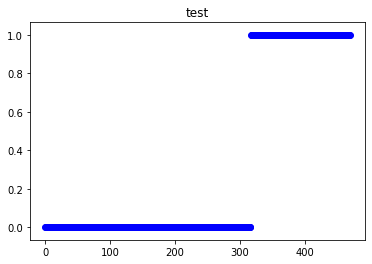

In [73]:
import matplotlib.pyplot as plt
import numpy as np


def plotGraph(y_test,y_pred,regressorName):
    if max(y_test) >= max(y_pred):
        my_range = int(max(y_test))
    else:
        my_range = int(max(y_pred))
    plt.scatter(range(len(y_test)), y_test, color='blue')
    #plt.scatter(range(len(y_pred)), y_pred, color='red')
    plt.title(regressorName)
    plt.show()
    return


plotGraph(y_test[0:470], y_pred[0:470], "test")